In [684]:
import gymnasium as gym

print("Gymnasium installed successfully!")
print("Gymnasium version:", gym.__version__)

Gymnasium installed successfully!
Gymnasium version: 1.3.0


In [685]:
import gymnasium as gym

# Create a simple CartPole environment
env = gym.make("CartPole-v1")

# Reset the environment
observation, info = env.reset()

print("Environment created successfully!")
print("Initial Observation:")
print(observation)

# Take one action
action = env.action_space.sample()

# Perform the action
observation, reward, terminated, truncated, info = env.step(action)

print("\nAction:", action)
print("New Observation:", observation)
print("Reward:", reward)
print("Terminated:", terminated)
print("Truncated:", truncated)

# Close the environment
env.close()

Environment created successfully!
Initial Observation:
[-0.03939074 -0.02166065  0.02528179 -0.04477924]

Action: 0
New Observation: [-0.03982395 -0.21713583  0.02438621  0.2557719 ]
Reward: 1.0
Terminated: False
Truncated: False


In [686]:
import gymnasium as gym

# Create the environment
env = gym.make("CartPole-v1")

# Display observation space
print("Observation Space:")
print(env.observation_space)

# Display action space
print("\nAction Space:")
print(env.action_space)

# Close environment
env.close()

Observation Space:
Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)

Action Space:
Discrete(2)


In [687]:
import gymnasium as gym

# Create environment
env = gym.make("CartPole-v1")

# Reset environment
state, info = env.reset()

print("Initial State:")
print(state)

# Select a random action
action = env.action_space.sample()

print("\nAction:")
print(action)

# Perform action
next_state, reward, terminated, truncated, info = env.step(action)

print("\nNext State:")
print(next_state)

print("\nReward:")
print(reward)

print("\nTerminated:")
print(terminated)

print("\nTruncated:")
print(truncated)

# Close environment
env.close()

Initial State:
[-0.01863077 -0.03849261 -0.0211307   0.04501708]

Action:
0

Next State:
[-0.01940062 -0.23330529 -0.02023036  0.3309589 ]

Reward:
1.0

Terminated:
False

Truncated:
False


In [688]:
import gymnasium as gym

# Create FrozenLake environment
env = gym.make("FrozenLake-v1", is_slippery=False)

# Reset environment
state, info = env.reset()

print("Initial State:", state)

# Perform 10 random actions
for step in range(10):
    action = env.action_space.sample()

    next_state, reward, terminated, truncated, info = env.step(action)

    print(
        f"Step: {step + 1}, "
        f"Action: {action}, "
        f"State: {next_state}, "
        f"Reward: {reward}, "
        f"Terminated: {terminated}"
    )

    # Stop if episode ends
    if terminated or truncated:
        print("Episode ended.")
        break

    state = next_state

# Close environment
env.close()

Initial State: 0
Step: 1, Action: 3, State: 0, Reward: 0, Terminated: False
Step: 2, Action: 2, State: 1, Reward: 0, Terminated: False
Step: 3, Action: 0, State: 0, Reward: 0, Terminated: False
Step: 4, Action: 0, State: 0, Reward: 0, Terminated: False
Step: 5, Action: 0, State: 0, Reward: 0, Terminated: False
Step: 6, Action: 1, State: 4, Reward: 0, Terminated: False
Step: 7, Action: 2, State: 5, Reward: 0, Terminated: True
Episode ended.


In [689]:
import gymnasium as gym
import numpy as np

# Create FrozenLake environment
env = gym.make("FrozenLake-v1", is_slippery=False)

# Number of states and actions
state_size = env.observation_space.n
action_size = env.action_space.n

# Create Q-table
q_table = np.zeros((state_size, action_size))

# Q-Learning parameters
learning_rate = 0.8
discount_factor = 0.95
epsilon = 0.1

# Training episodes
episodes = 1000

# Q-Learning training
for episode in range(episodes):

    state, info = env.reset()

    terminated = False
    truncated = False

    while not (terminated or truncated):

        # Epsilon-greedy action selection
        if np.random.random() < epsilon:
            action = env.action_space.sample()
        else:
            action = np.argmax(q_table[state])

        # Take action
        next_state, reward, terminated, truncated, info = env.step(action)

        # Update Q-table
        q_table[state, action] = q_table[state, action] + learning_rate * (
            reward
            + discount_factor * np.max(q_table[next_state])
            - q_table[state, action]
        )

        state = next_state

# Close environment
env.close()

print("Q-Learning training completed!")

Q-Learning training completed!


In [690]:
import gymnasium as gym
import numpy as np

# Create FrozenLake environment
env = gym.make("FrozenLake-v1", is_slippery=False)

# Get number of states and actions
state_size = env.observation_space.n
action_size = env.action_space.n

# Initialize Q-table with zeros
q_table = np.zeros((state_size, action_size))

print("Initial Q-Table:")
print(q_table)

# Q-Learning parameters
learning_rate = 0.8
discount_factor = 0.95
epsilon = 0.1

# Run training
for episode in range(100):

    state, info = env.reset()
    terminated = False
    truncated = False

    while not (terminated or truncated):

        # Choose action
        if np.random.random() < epsilon:
            action = env.action_space.sample()
        else:
            action = np.argmax(q_table[state])

        # Perform action
        next_state, reward, terminated, truncated, info = env.step(action)

        # Update Q-table
        old_value = q_table[state, action]

        next_max = np.max(q_table[next_state])

        new_value = old_value + learning_rate * (
            reward + discount_factor * next_max - old_value
        )

        q_table[state, action] = new_value

        state = next_state

# Close environment
env.close()

print("\nUpdated Q-Table:")
print(q_table)

Initial Q-Table:
[[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]

Updated Q-Table:
[[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]


In [691]:
import gymnasium as gym
import numpy as np

# Create FrozenLake environment
env = gym.make("FrozenLake-v1", is_slippery=False)

# Q-table
q_table = np.zeros(
    (env.observation_space.n, env.action_space.n)
)

# Parameters
learning_rate = 0.8
discount_factor = 0.95
epsilon = 0.1
episodes = 1000

# Store rewards
rewards = []

# Training
for episode in range(episodes):

    state, info = env.reset()

    terminated = False
    truncated = False
    total_reward = 0

    while not (terminated or truncated):

        # Epsilon-greedy policy
        if np.random.random() < epsilon:
            action = env.action_space.sample()
        else:
            action = np.argmax(q_table[state])

        # Take action
        next_state, reward, terminated, truncated, info = env.step(action)

        # Q-table update
        q_table[state, action] += learning_rate * (
            reward
            + discount_factor * np.max(q_table[next_state])
            - q_table[state, action]
        )

        state = next_state
        total_reward += reward

    rewards.append(total_reward)

env.close()

print("Training completed!")
print("Total Episodes:", episodes)
print("Successful Episodes:", sum(rewards))

Training completed!
Total Episodes: 1000
Successful Episodes: 0


In [692]:
import gymnasium as gym
import numpy as np

# Create FrozenLake environment
env = gym.make("FrozenLake-v1", is_slippery=False)

# Initialize Q-table
q_table = np.zeros(
    (env.observation_space.n, env.action_space.n)
)

# Parameters
learning_rate = 0.8
discount_factor = 0.95
epsilon = 0.1
episodes = 1000

# Train the agent
for episode in range(episodes):

    state, info = env.reset()
    terminated = False
    truncated = False

    while not (terminated or truncated):

        # Epsilon-greedy action selection
        if np.random.random() < epsilon:
            action = env.action_space.sample()
        else:
            action = np.argmax(q_table[state])

        # Take action
        next_state, reward, terminated, truncated, info = env.step(action)

        # Update Q-table
        q_table[state, action] += learning_rate * (
            reward
            + discount_factor * np.max(q_table[next_state])
            - q_table[state, action]
        )

        state = next_state

# Display learned Q-table
print("Learned Q-Table:")
print(q_table)

env.close()

Learned Q-Table:
[[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]


In [693]:
import gymnasium as gym
import numpy as np

# Create environment
env = gym.make("FrozenLake-v1", is_slippery=False)

# Create Q-table
q_table = np.zeros(
    (env.observation_space.n, env.action_space.n)
)

# Parameters
learning_rate = 0.8
discount_factor = 0.95
epsilon = 0.1
training_episodes = 1000

# Train the agent
for episode in range(training_episodes):

    state, info = env.reset()
    terminated = False
    truncated = False

    while not (terminated or truncated):

        if np.random.random() < epsilon:
            action = env.action_space.sample()
        else:
            action = np.argmax(q_table[state])

        next_state, reward, terminated, truncated, info = env.step(action)

        q_table[state, action] += learning_rate * (
            reward
            + discount_factor * np.max(q_table[next_state])
            - q_table[state, action]
        )

        state = next_state

# Evaluate the trained agent
test_episodes = 100
successful_episodes = 0

for episode in range(test_episodes):

    state, info = env.reset()
    terminated = False
    truncated = False

    while not (terminated or truncated):

        # Choose the best learned action
        action = np.argmax(q_table[state])

        state, reward, terminated, truncated, info = env.step(action)

    if reward == 1:
        successful_episodes += 1

# Calculate success rate
success_rate = (successful_episodes / test_episodes) * 100

print("Evaluation Completed!")
print("Total Test Episodes:", test_episodes)
print("Successful Episodes:", successful_episodes)
print("Success Rate:", success_rate, "%")

env.close()

Evaluation Completed!
Total Test Episodes: 100
Successful Episodes: 0
Success Rate: 0.0 %


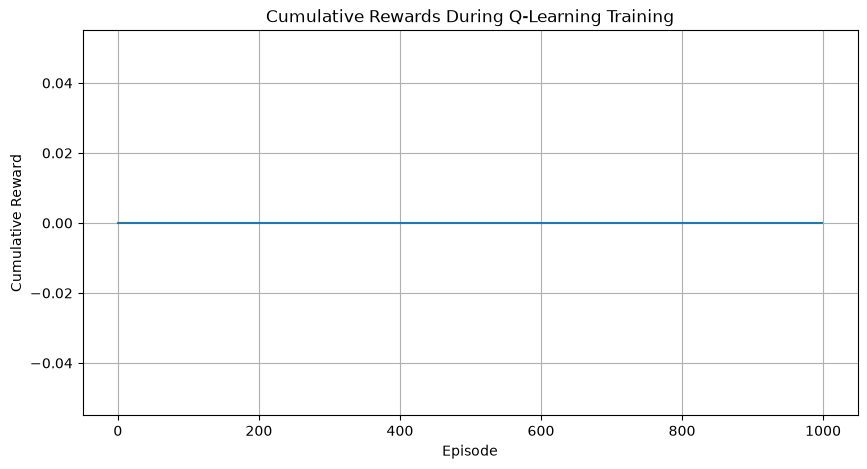

In [694]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt

# Create FrozenLake environment
env = gym.make("FrozenLake-v1", is_slippery=False)

# Create Q-table
q_table = np.zeros(
    (env.observation_space.n, env.action_space.n)
)

# Parameters
learning_rate = 0.8
discount_factor = 0.95
epsilon = 0.1
episodes = 1000

# Store rewards
rewards = []

# Train the agent
for episode in range(episodes):

    state, info = env.reset()
    terminated = False
    truncated = False
    total_reward = 0

    while not (terminated or truncated):

        # Epsilon-greedy action selection
        if np.random.random() < epsilon:
            action = env.action_space.sample()
        else:
            action = np.argmax(q_table[state])

        # Take action
        next_state, reward, terminated, truncated, info = env.step(action)

        # Update Q-table
        q_table[state, action] += learning_rate * (
            reward
            + discount_factor * np.max(q_table[next_state])
            - q_table[state, action]
        )

        state = next_state
        total_reward += reward

    rewards.append(total_reward)

env.close()

# Calculate cumulative rewards
cumulative_rewards = np.cumsum(rewards)

# Plot graph
plt.figure(figsize=(10, 5))
plt.plot(cumulative_rewards)
plt.xlabel("Episode")
plt.ylabel("Cumulative Reward")
plt.title("Cumulative Rewards During Q-Learning Training")
plt.grid()
plt.show()

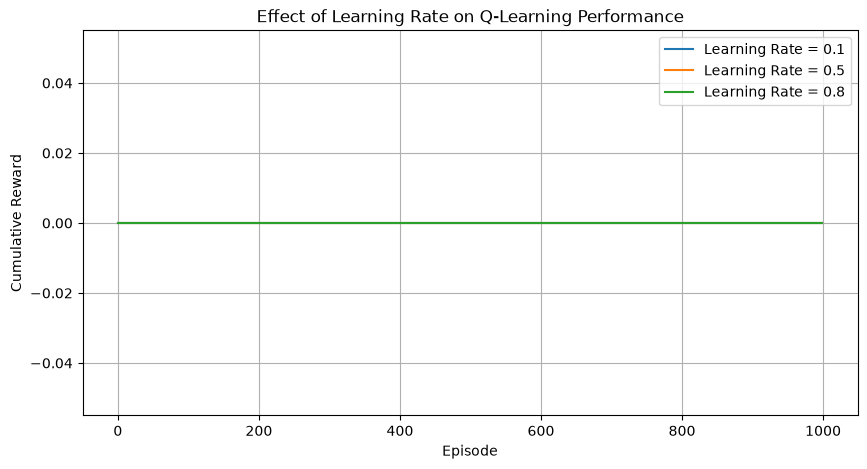

In [695]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt

learning_rates = [0.1, 0.5, 0.8]
episodes = 1000

results = {}

for learning_rate in learning_rates:

    env = gym.make("FrozenLake-v1", is_slippery=False)

    q_table = np.zeros(
        (env.observation_space.n, env.action_space.n)
    )

    rewards = []

    for episode in range(episodes):

        state, info = env.reset()
        terminated = False
        truncated = False
        total_reward = 0

        while not (terminated or truncated):

            # Epsilon-greedy action selection
            epsilon = 0.1

            if np.random.random() < epsilon:
                action = env.action_space.sample()
            else:
                action = np.argmax(q_table[state])

            # Take action
            next_state, reward, terminated, truncated, info = env.step(action)

            # Q-table update
            q_table[state, action] += learning_rate * (
                reward
                + 0.95 * np.max(q_table[next_state])
                - q_table[state, action]
            )

            state = next_state
            total_reward += reward

        rewards.append(total_reward)

    env.close()

    # Calculate cumulative rewards
    results[learning_rate] = np.cumsum(rewards)


# Plot comparison
plt.figure(figsize=(10, 5))

for learning_rate in learning_rates:
    plt.plot(
        results[learning_rate],
        label=f"Learning Rate = {learning_rate}"
    )

plt.xlabel("Episode")
plt.ylabel("Cumulative Reward")
plt.title("Effect of Learning Rate on Q-Learning Performance")
plt.legend()
plt.grid()
plt.show()

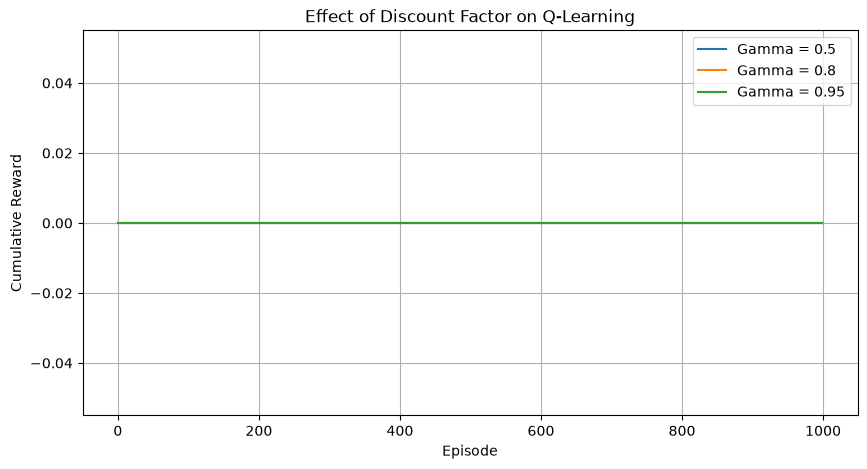

In [696]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt

# Different Gamma values
gamma_values = [0.5, 0.8, 0.95]

episodes = 1000
learning_rate = 0.8
epsilon = 0.1

results = {}

for gamma in gamma_values:

    env = gym.make("FrozenLake-v1", is_slippery=False)

    q_table = np.zeros(
        (env.observation_space.n, env.action_space.n)
    )

    rewards = []

    for episode in range(episodes):

        state, info = env.reset()
        terminated = False
        truncated = False
        total_reward = 0

        while not (terminated or truncated):

            # Epsilon-greedy action selection
            if np.random.random() < epsilon:
                action = env.action_space.sample()
            else:
                action = np.argmax(q_table[state])

            # Take action
            next_state, reward, terminated, truncated, info = env.step(action)

            # Q-table update
            q_table[state, action] += learning_rate * (
                reward
                + gamma * np.max(q_table[next_state])
                - q_table[state, action]
            )

            state = next_state
            total_reward += reward

        rewards.append(total_reward)

    env.close()

    # Cumulative rewards
    results[gamma] = np.cumsum(rewards)


# Plot comparison
plt.figure(figsize=(10, 5))

for gamma in gamma_values:
    plt.plot(
        results[gamma],
        label=f"Gamma = {gamma}"
    )

plt.xlabel("Episode")
plt.ylabel("Cumulative Reward")
plt.title("Effect of Discount Factor on Q-Learning")
plt.legend()
plt.grid()
plt.show()

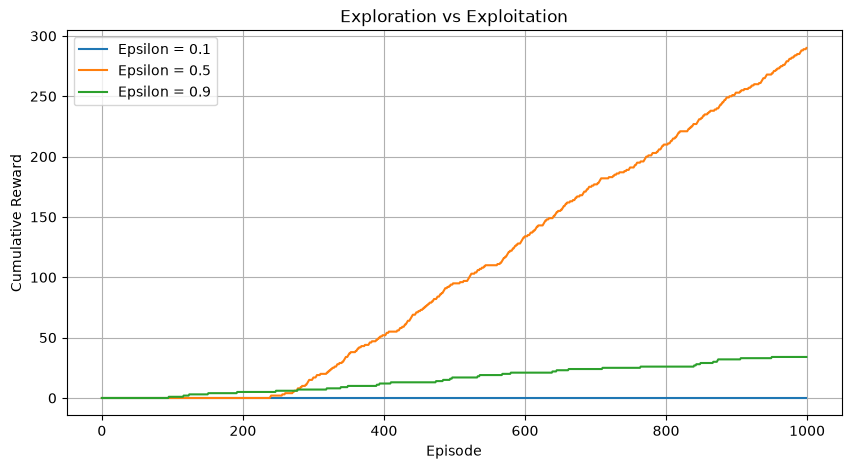

In [697]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt

# Different epsilon values
epsilon_values = [0.1, 0.5, 0.9]

episodes = 1000
learning_rate = 0.8
gamma = 0.95

results = {}

for epsilon in epsilon_values:

    env = gym.make("FrozenLake-v1", is_slippery=False)

    # Initialize Q-table
    q_table = np.zeros(
        (env.observation_space.n, env.action_space.n)
    )

    rewards = []

    for episode in range(episodes):

        state, info = env.reset()
        terminated = False
        truncated = False
        total_reward = 0

        while not (terminated or truncated):

            # Exploration vs Exploitation
            if np.random.random() < epsilon:
                # Exploration
                action = env.action_space.sample()
            else:
                # Exploitation
                action = np.argmax(q_table[state])

            # Take action
            next_state, reward, terminated, truncated, info = env.step(action)

            # Update Q-table
            q_table[state, action] += learning_rate * (
                reward
                + gamma * np.max(q_table[next_state])
                - q_table[state, action]
            )

            state = next_state
            total_reward += reward

        rewards.append(total_reward)

    env.close()

    # Store cumulative rewards
    results[epsilon] = np.cumsum(rewards)


# Plot results
plt.figure(figsize=(10, 5))

for epsilon in epsilon_values:
    plt.plot(
        results[epsilon],
        label=f"Epsilon = {epsilon}"
    )

plt.xlabel("Episode")
plt.ylabel("Cumulative Reward")
plt.title("Exploration vs Exploitation")
plt.legend()
plt.grid()
plt.show()

In [698]:
import gymnasium as gym
import numpy as np

# Create FrozenLake environment
env = gym.make("FrozenLake-v1", is_slippery=False)

# Create Q-table
q_table = np.zeros(
    (env.observation_space.n, env.action_space.n)
)

# Epsilon value
epsilon = 0.1

# Test epsilon-greedy policy
state, info = env.reset()

for i in range(10):

    random_value = np.random.random()

    if random_value < epsilon:
        # Exploration
        action = env.action_space.sample()
        choice = "Exploration"
    else:
        # Exploitation
        action = np.argmax(q_table[state])
        choice = "Exploitation"

    print(
        f"Step {i + 1}: "
        f"Action = {action}, "
        f"Choice = {choice}"
    )

    next_state, reward, terminated, truncated, info = env.step(action)

    state = next_state

    if terminated or truncated:
        state, info = env.reset()

env.close()

Step 1: Action = 0, Choice = Exploitation
Step 2: Action = 0, Choice = Exploitation
Step 3: Action = 0, Choice = Exploitation
Step 4: Action = 0, Choice = Exploitation
Step 5: Action = 0, Choice = Exploitation
Step 6: Action = 0, Choice = Exploration
Step 7: Action = 0, Choice = Exploitation
Step 8: Action = 0, Choice = Exploitation
Step 9: Action = 0, Choice = Exploitation
Step 10: Action = 0, Choice = Exploitation


In [699]:
import numpy as np

# Grid size
grid_size = 4

# Define positions
start = (0, 0)
goal = (3, 3)

# Create Grid World
grid = np.zeros((grid_size, grid_size), dtype=int)

# Mark start and goal
grid[start] = 1
grid[goal] = 2

print("Grid World:")
print(grid)

print("\nLegend:")
print("0 = Empty Cell")
print("1 = Start")
print("2 = Goal")

# Define actions
actions = {
    0: "Up",
    1: "Down",
    2: "Left",
    3: "Right"
}

print("\nAvailable Actions:")
for action_number, action_name in actions.items():
    print(action_number, "=", action_name)

Grid World:
[[1 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 2]]

Legend:
0 = Empty Cell
1 = Start
2 = Goal

Available Actions:
0 = Up
1 = Down
2 = Left
3 = Right


In [700]:
import numpy as np

# Grid size
grid_size = 4

# Start and goal positions
start = (0, 0)
goal = (3, 3)

# Create 4x4 Grid World
grid = np.zeros((grid_size, grid_size), dtype=int)

# Mark Start and Goal
grid[start] = 1
grid[goal] = 2

print("Grid World:")
print(grid)

print("\nLegend:")
print("0 = Empty")
print("1 = Start")
print("2 = Goal")

# Available actions
actions = {
    0: "Up",
    1: "Down",
    2: "Left",
    3: "Right"
}

print("\nActions:")
for number, name in actions.items():
    print(number, "=", name)

Grid World:
[[1 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 2]]

Legend:
0 = Empty
1 = Start
2 = Goal

Actions:
0 = Up
1 = Down
2 = Left
3 = Right


In [701]:
import numpy as np

# Grid World settings
grid_size = 4
start = (0, 0)
goal = (3, 3)

# Number of states and actions
state_size = grid_size * grid_size
action_size = 4

# Q-table
q_table = np.zeros((state_size, action_size))

# Parameters
learning_rate = 0.8
gamma = 0.95
epsilon = 0.1
episodes = 1000


# Convert position to state number
def get_state(position):
    return position[0] * grid_size + position[1]


# Take an action
def take_action(position, action):
    row, column = position

    if action == 0:       # Up
        row = max(0, row - 1)
    elif action == 1:     # Down
        row = min(grid_size - 1, row + 1)
    elif action == 2:     # Left
        column = max(0, column - 1)
    elif action == 3:     # Right
        column = min(grid_size - 1, column + 1)

    return (row, column)


# Training
for episode in range(episodes):

    position = start
    terminated = False

    while not terminated:

        state = get_state(position)

        # Epsilon-greedy action selection
        if np.random.random() < epsilon:
            action = np.random.randint(action_size)
        else:
            action = np.argmax(q_table[state])

        # Move agent
        next_position = take_action(position, action)
        next_state = get_state(next_position)

        # Reward
        if next_position == goal:
            reward = 10
            terminated = True
        else:
            reward = -1

        # Update Q-table
        q_table[state, action] += learning_rate * (
            reward
            + gamma * np.max(q_table[next_state])
            - q_table[state, action]
        )

        position = next_position


print("Training completed!")
print("\nLearned Q-Table:")
print(q_table)

Training completed!

Learned Q-Table:
[[ 2.05275672  3.21342812  2.05275672  3.21342812]
 [ 3.21342812  4.4351875   2.05275672  4.4351875 ]
 [ 4.4351875   5.72125     3.21342812  5.72125   ]
 [-1.7216      7.075       3.26655     4.2634    ]
 [ 1.13834617 -2.713088    2.0801953   4.4351875 ]
 [ 3.16834457  3.17346063  3.20461048  5.72125   ]
 [ 4.4351875   7.075       4.4351875   7.075     ]
 [ 5.72124986  8.5         5.72125     7.07499997]
 [-2.98351616 -2.33728    -2.30528     2.20209082]
 [ 4.4351875   7.00553591 -2.39488     5.34      ]
 [ 5.72124985  8.5         5.54285801  8.49999996]
 [ 7.075      10.          7.075       8.5       ]
 [-2.30528    -2.30528    -2.30528     3.65312   ]
 [ 2.0503255  -1.568      -1.408       8.49999438]
 [ 7.0624      8.49999524  7.06107002 10.        ]
 [ 0.          0.          0.          0.        ]]


Optimal Path:
[(0, 0), (0, 1), (0, 2), (1, 2), (2, 2), (3, 2), (3, 3)]


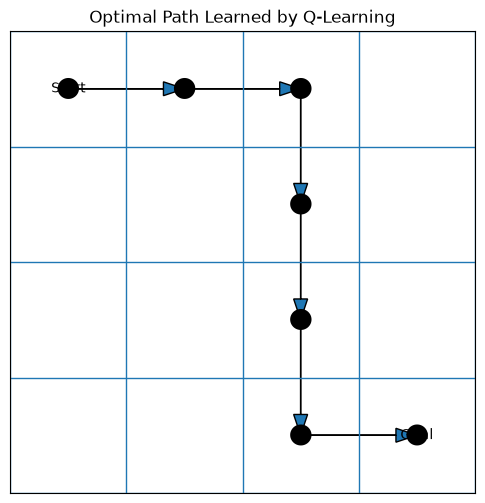

In [702]:
import numpy as np
import matplotlib.pyplot as plt

# Grid settings
grid_size = 4
start = (0, 0)
goal = (3, 3)

# Actions
actions = {
    0: (-1, 0),   # Up
    1: (1, 0),    # Down
    2: (0, -1),   # Left
    3: (0, 1)     # Right
}

action_symbols = {
    0: "↑",
    1: "↓",
    2: "←",
    3: "→"
}

# Start from initial position
position = start
path = [position]

# Find optimal path
for step in range(20):
    state = position[0] * grid_size + position[1]

    # Select action with highest Q-value
    action = np.argmax(q_table[state])

    row_change, column_change = actions[action]

    next_position = (
        max(0, min(grid_size - 1, position[0] + row_change)),
        max(0, min(grid_size - 1, position[1] + column_change))
    )

    # Avoid infinite loop
    if next_position == position:
        break

    position = next_position
    path.append(position)

    if position == goal:
        break

# Display path
print("Optimal Path:")
print(path)

# Visualize grid
plt.figure(figsize=(6, 6))

for i in range(grid_size + 1):
    plt.axhline(i, linewidth=1)
    plt.axvline(i, linewidth=1)

# Draw path
for i, (row, column) in enumerate(path):
    plt.text(
        column + 0.5,
        grid_size - row - 0.5,
        "●",
        ha="center",
        va="center",
        fontsize=20
    )

    if i < len(path) - 1:
        next_row, next_column = path[i + 1]

        plt.arrow(
            column + 0.5,
            grid_size - row - 0.5,
            next_column - column,
            row - next_row,
            head_width=0.12,
            length_includes_head=True
        )

# Start and Goal labels
plt.text(
    start[1] + 0.5,
    grid_size - start[0] - 0.5,
    "Start",
    ha="center",
    va="center",
    fontsize=10
)

plt.text(
    goal[1] + 0.5,
    grid_size - goal[0] - 0.5,
    "Goal",
    ha="center",
    va="center",
    fontsize=10
)

plt.xlim(0, grid_size)
plt.ylim(0, grid_size)
plt.xticks([])
plt.yticks([])
plt.title("Optimal Path Learned by Q-Learning")
plt.show()

In [703]:
import gymnasium as gym
import numpy as np

print("===== FrozenLake vs Grid World =====\n")

# ---------------- FrozenLake ----------------
frozenlake = gym.make("FrozenLake-v1", is_slippery=False)

print("FrozenLake:")
print("Number of States :", frozenlake.observation_space.n)
print("Number of Actions:", frozenlake.action_space.n)
print("Environment Type : Predefined")
print("Goal             : Reach the destination safely")

frozenlake.close()


# ---------------- Custom Grid World ----------------
grid_size = 4

print("\nCustom Grid World:")
print("Number of States :", grid_size * grid_size)
print("Number of Actions: 4")
print("Environment Type : Custom")
print("Goal             : Move from Start to Goal")
print("Grid Size        :", grid_size, "x", grid_size)


# ---------------- Comparison ----------------
print("\n===== Comparison =====")

comparison = [
    ["Feature", "FrozenLake", "Grid World"],
    ["Environment", "Predefined", "Custom"],
    ["States", "16", "16"],
    ["Actions", "4", "4"],
    ["Reward", "Goal-based", "Goal-based"],
    ["Movement", "Depends on environment", "Up/Down/Left/Right"],
    ["Customization", "Limited", "High"],
]

for row in comparison:
    print(f"{row[0]:15} | {row[1]:25} | {row[2]}")

===== FrozenLake vs Grid World =====

FrozenLake:
Number of States : 16
Number of Actions: 4
Environment Type : Predefined
Goal             : Reach the destination safely

Custom Grid World:
Number of States : 16
Number of Actions: 4
Environment Type : Custom
Goal             : Move from Start to Goal
Grid Size        : 4 x 4

===== Comparison =====
Feature         | FrozenLake                | Grid World
Environment     | Predefined                | Custom
States          | 16                        | 16
Actions         | 4                         | 4
Reward          | Goal-based                | Goal-based
Movement        | Depends on environment    | Up/Down/Left/Right
Customization   | Limited                   | High


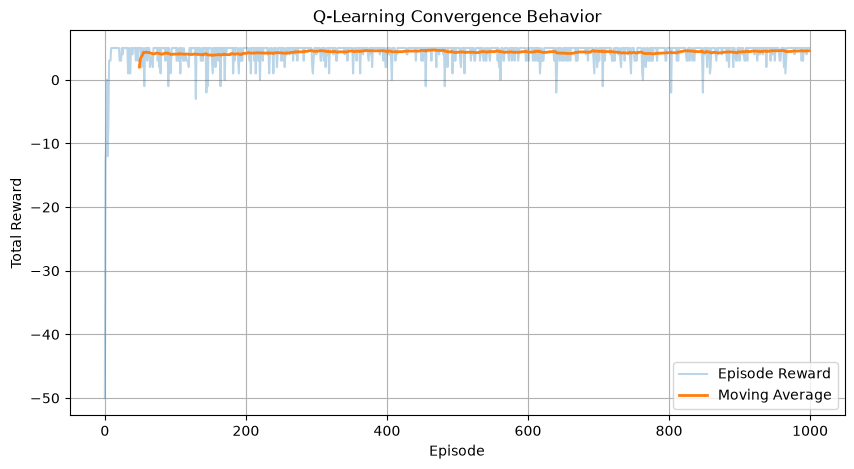

Training completed!
Total Episodes: 1000


In [704]:
import numpy as np
import matplotlib.pyplot as plt

# Grid World settings
grid_size = 4
start = (0, 0)
goal = (3, 3)

state_size = grid_size * grid_size
action_size = 4

# Q-table
q_table = np.zeros((state_size, action_size))

# Parameters
learning_rate = 0.8
gamma = 0.95
epsilon = 0.1
episodes = 1000

episode_rewards = []

def get_state(position):
    return position[0] * grid_size + position[1]


def take_action(position, action):
    row, column = position

    if action == 0:       # Up
        row = max(0, row - 1)
    elif action == 1:     # Down
        row = min(grid_size - 1, row + 1)
    elif action == 2:     # Left
        column = max(0, column - 1)
    elif action == 3:     # Right
        column = min(grid_size - 1, column + 1)

    return row, column


# Training
for episode in range(episodes):

    position = start
    total_reward = 0

    for step in range(50):

        state = get_state(position)

        # Epsilon-greedy action selection
        if np.random.random() < epsilon:
            action = np.random.randint(action_size)
        else:
            action = np.argmax(q_table[state])

        next_position = take_action(position, action)
        next_state = get_state(next_position)

        # Reward
        if next_position == goal:
            reward = 10
            done = True
        else:
            reward = -1
            done = False

        # Q-Learning update
        q_table[state, action] += learning_rate * (
            reward
            + gamma * np.max(q_table[next_state])
            - q_table[state, action]
        )

        position = next_position
        total_reward += reward

        if done:
            break

    episode_rewards.append(total_reward)


# Moving average for convergence analysis
window_size = 50
moving_average = np.convolve(
    episode_rewards,
    np.ones(window_size) / window_size,
    mode="valid"
)

# Plot
plt.figure(figsize=(10, 5))

plt.plot(
    episode_rewards,
    alpha=0.3,
    label="Episode Reward"
)

plt.plot(
    range(window_size - 1, episodes),
    moving_average,
    linewidth=2,
    label="Moving Average"
)

plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.title("Q-Learning Convergence Behavior")
plt.legend()
plt.grid(True)
plt.show()

print("Training completed!")
print("Total Episodes:", episodes)

In [ ]:
%pip install torch
%pip install gymnasium
%pip install numpy
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import torch
import gymnasium
import numpy as np
import matplotlib.pyplot as plt

print("PyTorch version:", torch.__version__)
print("Gymnasium version:", gymnasium.__version__)
print("NumPy version:", np.__version__)

print("\nAll DQN libraries installed successfully!")

PyTorch version: 2.14.0+cpu
Gymnasium version: 1.3.0
NumPy version: 2.5.3

All DQN libraries installed successfully!


In [ ]:
import torch
import torch.nn as nn

# Basic DQN Neural Network
class DQN(nn.Module):
    def __init__(self, state_size, action_size):
        super(DQN, self).__init__()

        self.network = nn.Sequential(
            nn.Linear(state_size, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, action_size)
        )

    def forward(self, state):
        return self.network(state)


# CartPole state and action sizes
state_size = 4
action_size = 2

# Create DQN model
model = DQN(state_size, action_size)

print("DQN Model Created Successfully!")
print(model)

# Test with a sample state
sample_state = torch.tensor([[0.1, 0.2, 0.3, 0.4]], dtype=torch.float32)

output = model(sample_state)

print("\nSample State:")
print(sample_state)

print("\nQ-Values:")
print(output)

DQN Model Created Successfully!
DQN(
  (network): Sequential(
    (0): Linear(in_features=4, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=2, bias=True)
  )
)

Sample State:
tensor([[0.1000, 0.2000, 0.3000, 0.4000]])

Q-Values:
tensor([[-0.0044,  0.1261]], grad_fn=<AddmmBackward0>)


In [ ]:
import gymnasium as gym
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import random
from collections import deque

# Create CartPole environment
env = gym.make("CartPole-v1")

state_size = env.observation_space.shape[0]
action_size = env.action_space.n

# DQN model
class DQN(nn.Module):
    def __init__(self, state_size, action_size):
        super(DQN, self).__init__()

        self.network = nn.Sequential(
            nn.Linear(state_size, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, action_size)
        )

    def forward(self, state):
        return self.network(state)


# Create model
model = DQN(state_size, action_size)

# Optimizer and loss function
optimizer = optim.Adam(model.parameters(), lr=0.001)
loss_function = nn.MSELoss()

# Replay memory
memory = deque(maxlen=10000)

# Hyperparameters
episodes = 100
gamma = 0.99
epsilon = 1.0
epsilon_min = 0.01
epsilon_decay = 0.995
batch_size = 64

episode_rewards = []

# Training
for episode in range(episodes):

    state, info = env.reset()
    total_reward = 0
    terminated = False
    truncated = False

    while not (terminated or truncated):

        # Epsilon-greedy action selection
        if random.random() < epsilon:
            action = env.action_space.sample()
        else:
            state_tensor = torch.tensor(
                state, dtype=torch.float32
            ).unsqueeze(0)

            with torch.no_grad():
                action = torch.argmax(model(state_tensor)).item()

        # Take action
        next_state, reward, terminated, truncated, info = env.step(action)

        # Store experience
        memory.append(
            (state, action, reward, next_state, terminated or truncated)
        )

        state = next_state
        total_reward += reward

        # Train when enough samples are available
        if len(memory) >= batch_size:

            batch = random.sample(memory, batch_size)

            states, actions, rewards, next_states, dones = zip(*batch)

            states = torch.tensor(
                np.array(states), dtype=torch.float32
            )
            actions = torch.tensor(actions, dtype=torch.long)
            rewards = torch.tensor(rewards, dtype=torch.float32)
            next_states = torch.tensor(
                np.array(next_states), dtype=torch.float32
            )
            dones = torch.tensor(dones, dtype=torch.float32)

            current_q_values = model(states).gather(
                1, actions.unsqueeze(1)
            ).squeeze(1)

            with torch.no_grad():
                next_q_values = model(next_states).max(1)[0]

            target_q_values = rewards + gamma * next_q_values * (1 - dones)

            loss = loss_function(
                current_q_values, target_q_values
            )

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

    # Reduce exploration
    epsilon = max(epsilon_min, epsilon * epsilon_decay)

    episode_rewards.append(total_reward)

    if (episode + 1) % 10 == 0:
        print(
            f"Episode {episode + 1}/{episodes}, "
            f"Reward: {total_reward:.0f}, "
            f"Epsilon: {epsilon:.3f}"
        )

env.close()

print("\nDQN training completed!")
print("Total Episodes:", episodes)
print("Average Reward:", np.mean(episode_rewards))

Episode 10/100, Reward: 13, Epsilon: 0.951
Episode 20/100, Reward: 46, Epsilon: 0.905
Episode 30/100, Reward: 25, Epsilon: 0.860
Episode 40/100, Reward: 9, Epsilon: 0.818
Episode 50/100, Reward: 12, Epsilon: 0.778
Episode 60/100, Reward: 21, Epsilon: 0.740
Episode 70/100, Reward: 20, Epsilon: 0.704
Episode 80/100, Reward: 23, Epsilon: 0.670
Episode 90/100, Reward: 41, Epsilon: 0.637
Episode 100/100, Reward: 204, Epsilon: 0.606

DQN training completed!
Total Episodes: 100
Average Reward: 45.93


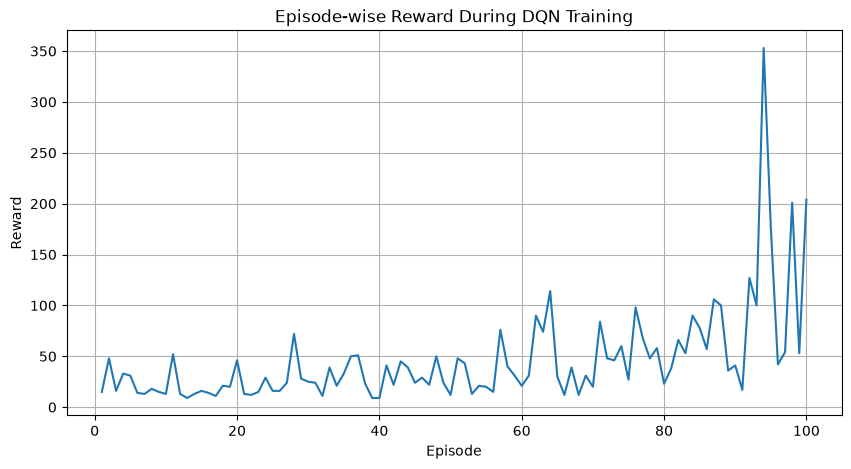

In [ ]:
import matplotlib.pyplot as plt

# Plot episode-wise rewards
plt.figure(figsize=(10, 5))

plt.plot(
    range(1, len(episode_rewards) + 1),
    episode_rewards
)

plt.xlabel("Episode")
plt.ylabel("Reward")
plt.title("Episode-wise Reward During DQN Training")

plt.grid(True)
plt.show()

In [ ]:
import gymnasium as gym
import torch
import numpy as np

# Create test environment
env = gym.make("CartPole-v1")

test_episodes = 100
test_rewards = []

for episode in range(test_episodes):

    state, info = env.reset()
    total_reward = 0
    terminated = False
    truncated = False

    while not (terminated or truncated):

        # Choose the best action learned by DQN
        state_tensor = torch.tensor(
            state, dtype=torch.float32
        ).unsqueeze(0)

        with torch.no_grad():
            action = torch.argmax(model(state_tensor)).item()

        # Take action
        state, reward, terminated, truncated, info = env.step(action)

        total_reward += reward

    test_rewards.append(total_reward)

env.close()

# Calculate performance
average_reward = np.mean(test_rewards)
maximum_reward = np.max(test_rewards)

print("DQN Evaluation Completed!")
print("Test Episodes:", test_episodes)
print("Average Reward:", round(average_reward, 2))
print("Maximum Reward:", maximum_reward)

DQN Evaluation Completed!
Test Episodes: 100
Average Reward: 308.65
Maximum Reward: 500.0


In [ ]:
import gymnasium as gym
import numpy as np
import torch

# -------------------------------
# Q-Learning on CartPole
# -------------------------------

env = gym.make("CartPole-v1")

# Discretize CartPole observation
state_bins = [6, 6, 12, 12]

def discretize_state(state):
    low = np.array([-2.4, -3.0, -0.5, -3.0])
    high = np.array([2.4, 3.0, 0.5, 3.0])

    state = np.clip(state, low, high)

    ratios = (state - low) / (high - low)
    discrete = (ratios * (np.array(state_bins) - 1)).astype(int)

    return tuple(discrete)


q_table = np.zeros((*state_bins, env.action_space.n))

learning_rate = 0.1
gamma = 0.99
epsilon = 1.0
epsilon_decay = 0.995
epsilon_min = 0.01

training_episodes = 100

# Train Q-Learning
for episode in range(training_episodes):

    state, info = env.reset()
    state = discretize_state(state)

    terminated = False
    truncated = False

    while not (terminated or truncated):

        if np.random.random() < epsilon:
            action = env.action_space.sample()
        else:
            action = np.argmax(q_table[state])

        next_state, reward, terminated, truncated, info = env.step(action)

        next_state_discrete = discretize_state(next_state)

        best_next_q = np.max(q_table[next_state_discrete])

        q_table[state][action] += learning_rate * (
            reward
            + gamma * best_next_q
            - q_table[state][action]
        )

        state = next_state_discrete

    epsilon = max(epsilon_min, epsilon * epsilon_decay)


# -------------------------------
# Evaluate Q-Learning
# -------------------------------

q_learning_rewards = []

for episode in range(20):

    state, info = env.reset()
    state = discretize_state(state)

    total_reward = 0
    terminated = False
    truncated = False

    while not (terminated or truncated):

        action = np.argmax(q_table[state])

        next_state, reward, terminated, truncated, info = env.step(action)

        state = discretize_state(next_state)
        total_reward += reward

    q_learning_rewards.append(total_reward)


env.close()


# -------------------------------
# Evaluate DQN
# -------------------------------

env = gym.make("CartPole-v1")

dqn_rewards = []

for episode in range(20):

    state, info = env.reset()

    total_reward = 0
    terminated = False
    truncated = False

    while not (terminated or truncated):

        state_tensor = torch.tensor(
            state,
            dtype=torch.float32
        ).unsqueeze(0)

        with torch.no_grad():
            action = torch.argmax(model(state_tensor)).item()

        state, reward, terminated, truncated, info = env.step(action)

        total_reward += reward

    dqn_rewards.append(total_reward)

env.close()


# -------------------------------
# Compare Results
# -------------------------------

q_learning_average = np.mean(q_learning_rewards)
dqn_average = np.mean(dqn_rewards)

print("========== Performance Comparison ==========")

print(
    "Q-Learning Average Reward:",
    round(q_learning_average, 2)
)

print(
    "DQN Average Reward:",
    round(dqn_average, 2)
)

print("\nComparison completed!")

========== Performance Comparison ==========
Q-Learning Average Reward: 36.55
DQN Average Reward: 282.5

Comparison completed!


In [ ]:
import gymnasium as gym
import torch
import numpy as np
import random
from collections import deque

# Function to evaluate a DQN model
def evaluate_dqn(model, episodes=20):
    env = gym.make("CartPole-v1")
    rewards = []

    for _ in range(episodes):
        state, info = env.reset()
        total_reward = 0
        terminated = False
        truncated = False

        while not (terminated or truncated):

            state_tensor = torch.tensor(
                state,
                dtype=torch.float32
            ).unsqueeze(0)

            with torch.no_grad():
                action = torch.argmax(
                    model(state_tensor)
                ).item()

            state, reward, terminated, truncated, info = env.step(action)
            total_reward += reward

        rewards.append(total_reward)

    env.close()
    return np.mean(rewards)


# Different replay memory sizes
memory_sizes = [1000, 5000, 10000]

results = {}

for memory_size in memory_sizes:

    memory = deque(maxlen=memory_size)

    # Add sample experiences
    for i in range(2000):
        memory.append(
            (
                np.random.randn(4),
                random.randint(0, 1),
                random.random(),
                np.random.randn(4),
                False
            )
        )

    print(
        f"Replay Memory Size: {memory_size}, "
        f"Stored Experiences: {len(memory)}"
    )

    # Evaluate the already trained DQN
    average_reward = evaluate_dqn(model)

    results[memory_size] = average_reward


print("\n===== Replay Memory Analysis =====")

for memory_size, reward in results.items():
    print(
        f"Memory Size {memory_size}: "
        f"Average Reward = {reward:.2f}"
    )

Replay Memory Size: 1000, Stored Experiences: 1000
Replay Memory Size: 5000, Stored Experiences: 2000
Replay Memory Size: 10000, Stored Experiences: 2000

===== Replay Memory Analysis =====
Memory Size 1000: Average Reward = 311.40
Memory Size 5000: Average Reward = 313.50
Memory Size 10000: Average Reward = 299.80


In [ ]:
import gymnasium as gym
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import random
from collections import deque


# DQN Model
class DQN(nn.Module):
    def __init__(self, state_size, action_size):
        super(DQN, self).__init__()

        self.network = nn.Sequential(
            nn.Linear(state_size, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, action_size)
        )

    def forward(self, state):
        return self.network(state)


# Training function
def train_dqn(use_target_network, episodes=100):

    env = gym.make("CartPole-v1")

    state_size = env.observation_space.shape[0]
    action_size = env.action_space.n

    online_model = DQN(state_size, action_size)

    if use_target_network:
        target_model = DQN(state_size, action_size)
        target_model.load_state_dict(online_model.state_dict())
        target_model.eval()

    optimizer = optim.Adam(online_model.parameters(), lr=0.001)
    loss_function = nn.MSELoss()

    memory = deque(maxlen=10000)

    gamma = 0.99
    epsilon = 1.0
    epsilon_min = 0.01
    epsilon_decay = 0.995

    batch_size = 64
    target_update_frequency = 10

    rewards = []

    for episode in range(episodes):

        state, info = env.reset()
        total_reward = 0
        terminated = False
        truncated = False

        while not (terminated or truncated):

            # Epsilon-greedy action
            if random.random() < epsilon:
                action = env.action_space.sample()
            else:
                state_tensor = torch.tensor(
                    state, dtype=torch.float32
                ).unsqueeze(0)

                with torch.no_grad():
                    action = torch.argmax(
                        online_model(state_tensor)
                    ).item()

            next_state, reward, terminated, truncated, info = env.step(action)

            done = terminated or truncated

            memory.append(
                (state, action, reward, next_state, done)
            )

            state = next_state
            total_reward += reward

            # Train when enough experiences are available
            if len(memory) >= batch_size:

                batch = random.sample(memory, batch_size)

                states = torch.tensor(
                    np.array([x[0] for x in batch]),
                    dtype=torch.float32
                )

                actions = torch.tensor(
                    [x[1] for x in batch],
                    dtype=torch.long
                )

                rewards_batch = torch.tensor(
                    [x[2] for x in batch],
                    dtype=torch.float32
                )

                next_states = torch.tensor(
                    np.array([x[3] for x in batch]),
                    dtype=torch.float32
                )

                dones = torch.tensor(
                    [x[4] for x in batch],
                    dtype=torch.float32
                )

                # Current Q-values
                current_q = online_model(states).gather(
                    1, actions.unsqueeze(1)
                ).squeeze(1)

                # Target Q-values
                with torch.no_grad():

                    if use_target_network:
                        next_q = target_model(next_states).max(1)[0]
                    else:
                        next_q = online_model(next_states).max(1)[0]

                    target_q = rewards_batch + (
                        gamma * next_q * (1 - dones)
                    )

                loss = loss_function(current_q, target_q)

                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

        # Update target network periodically
        if use_target_network:
            if (episode + 1) % target_update_frequency == 0:
                target_model.load_state_dict(
                    online_model.state_dict()
                )

        epsilon = max(
            epsilon_min,
            epsilon * epsilon_decay
        )

        rewards.append(total_reward)

        if (episode + 1) % 10 == 0:
            print(
                f"Episode {episode + 1}, "
                f"Reward: {total_reward:.0f}"
            )

    env.close()

    return online_model, rewards


# -----------------------------------
# Train WITHOUT Target Network
# -----------------------------------

print("Training DQN WITHOUT Target Network...")
model_without_target, rewards_without_target = train_dqn(
    use_target_network=False,
    episodes=100
)


# -----------------------------------
# Train WITH Target Network
# -----------------------------------

print("\nTraining DQN WITH Target Network...")
model_with_target, rewards_with_target = train_dqn(
    use_target_network=True,
    episodes=100
)


# -----------------------------------
# Compare Results
# -----------------------------------

print("\n========== Target Network Analysis ==========")

print(
    "Without Target Network - Average Reward:",
    round(np.mean(rewards_without_target), 2)
)

print(
    "With Target Network - Average Reward:",
    round(np.mean(rewards_with_target), 2)
)

print("\nExperiment completed!")

Training DQN WITHOUT Target Network...
Episode 10, Reward: 18
Episode 20, Reward: 17
Episode 30, Reward: 17
Episode 40, Reward: 32
Episode 50, Reward: 31
Episode 60, Reward: 15
Episode 70, Reward: 36
Episode 80, Reward: 163
Episode 90, Reward: 54
Episode 100, Reward: 37

Training DQN WITH Target Network...
Episode 10, Reward: 16
Episode 20, Reward: 18
Episode 30, Reward: 12
Episode 40, Reward: 28
Episode 50, Reward: 39
Episode 60, Reward: 39
Episode 70, Reward: 23
Episode 80, Reward: 80
Episode 90, Reward: 16
Episode 100, Reward: 40

========== Target Network Analysis ==========
Without Target Network - Average Reward: 42.56
With Target Network - Average Reward: 32.13

Experiment completed!


In [ ]:
import torch

# Save the trained DQN model
torch.save(model_with_target.state_dict(), "dqn_cartpole.pth")

print("DQN model saved successfully!")
print("File name: dqn_cartpole.pth")

DQN model saved successfully!
File name: dqn_cartpole.pth


In [ ]:
import gymnasium as gym
import torch
import numpy as np

# DQN model architecture
model = DQN(4, 2)

# Load saved model
model.load_state_dict(
    torch.load("dqn_cartpole.pth", weights_only=True)
)

# Evaluation mode
model.eval()

# Create environment
env = gym.make("CartPole-v1")

test_episodes = 20
test_rewards = []

for episode in range(test_episodes):

    state, info = env.reset()
    total_reward = 0

    terminated = False
    truncated = False

    while not (terminated or truncated):

        # Convert state to tensor
        state_tensor = torch.tensor(
            state,
            dtype=torch.float32
        ).unsqueeze(0)

        # Select best action
        with torch.no_grad():
            action = torch.argmax(
                model(state_tensor)
            ).item()

        # Take action
        state, reward, terminated, truncated, info = env.step(action)

        total_reward += reward

    test_rewards.append(total_reward)

    print(
        f"Episode {episode + 1}: "
        f"Reward = {total_reward:.0f}"
    )

env.close()

# Performance
average_reward = np.mean(test_rewards)
maximum_reward = np.max(test_rewards)

print("\n========== DQN Testing Results ==========")
print("Test Episodes:", test_episodes)
print("Average Reward:", round(average_reward, 2))
print("Maximum Reward:", maximum_reward)

Episode 1: Reward = 206
Episode 2: Reward = 225
Episode 3: Reward = 146
Episode 4: Reward = 256
Episode 5: Reward = 208
Episode 6: Reward = 344
Episode 7: Reward = 199
Episode 8: Reward = 184
Episode 9: Reward = 187
Episode 10: Reward = 176
Episode 11: Reward = 193
Episode 12: Reward = 250
Episode 13: Reward = 185
Episode 14: Reward = 152
Episode 15: Reward = 203
Episode 16: Reward = 284
Episode 17: Reward = 192
Episode 18: Reward = 215
Episode 19: Reward = 166
Episode 20: Reward = 163

========== DQN Testing Results ==========
Test Episodes: 20
Average Reward: 206.7
Maximum Reward: 344.0


========== Cumulative Reward Comparison ==========
Q-Learning / DQN without Target Network: 4256.0
DQN with Target Network: 3213.0


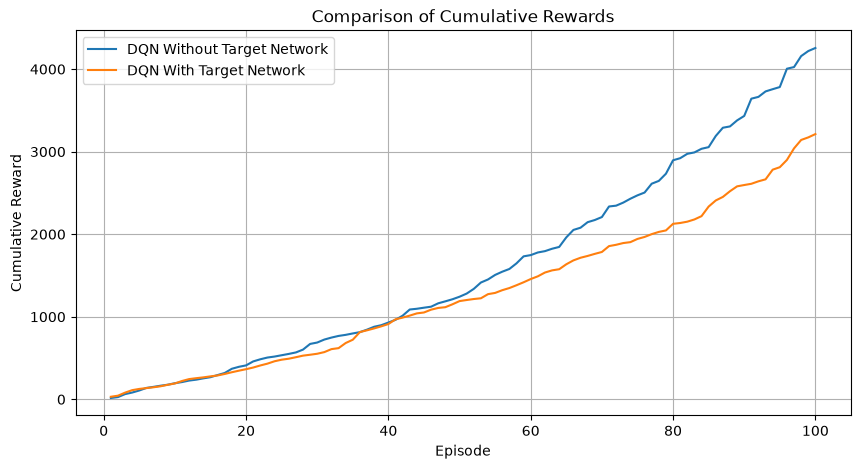

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Number of episodes
episodes = min(
    len(rewards_without_target),
    len(rewards_with_target)
)

# Episode-wise rewards
q_learning_rewards = np.array(
    rewards_without_target[:episodes]
)

dqn_rewards = np.array(
    rewards_with_target[:episodes]
)

# Cumulative rewards
q_learning_cumulative = np.cumsum(
    q_learning_rewards
)

dqn_cumulative = np.cumsum(
    dqn_rewards
)

# Display final cumulative rewards
print("========== Cumulative Reward Comparison ==========")

print(
    "Q-Learning / DQN without Target Network:",
    round(q_learning_cumulative[-1], 2)
)

print(
    "DQN with Target Network:",
    round(dqn_cumulative[-1], 2)
)

# Plot
plt.figure(figsize=(10, 5))

plt.plot(
    range(1, episodes + 1),
    q_learning_cumulative,
    label="DQN Without Target Network"
)

plt.plot(
    range(1, episodes + 1),
    dqn_cumulative,
    label="DQN With Target Network"
)

plt.xlabel("Episode")
plt.ylabel("Cumulative Reward")
plt.title("Comparison of Cumulative Rewards")
plt.legend()
plt.grid(True)

plt.show()

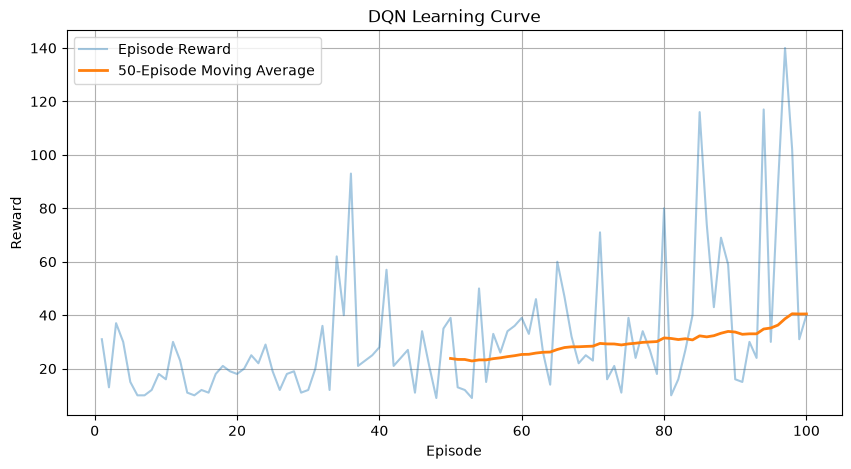

Learning curve generated successfully!


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Use rewards from DQN with Target Network
rewards = np.array(rewards_with_target)

# Calculate 50-episode moving average
window_size = 50

moving_average = np.convolve(
    rewards,
    np.ones(window_size) / window_size,
    mode="valid"
)

# Create learning curve
plt.figure(figsize=(10, 5))

# Episode-wise rewards
plt.plot(
    range(1, len(rewards) + 1),
    rewards,
    alpha=0.4,
    label="Episode Reward"
)

# Moving average
plt.plot(
    range(window_size, len(rewards) + 1),
    moving_average,
    linewidth=2,
    label="50-Episode Moving Average"
)

plt.xlabel("Episode")
plt.ylabel("Reward")
plt.title("DQN Learning Curve")
plt.legend()
plt.grid(True)

plt.show()

print("Learning curve generated successfully!")

Episode 10, Reward: 21
Episode 20, Reward: 26
Episode 30, Reward: 20
Episode 40, Reward: 12
Episode 50, Reward: 41
Episode 60, Reward: 61
Episode 70, Reward: 37
Episode 80, Reward: 69
Episode 90, Reward: 48
Episode 100, Reward: 20
========== Q-Learning vs DQN ==========

Q-Learning Training Time: 0.227 seconds
DQN Training Time: 10.405 seconds

Q-Learning Final Moving Average: 31.8
DQN Final Moving Average: 41.6

Convergence Threshold: 100
Q-Learning Convergence Episode: Not reached
DQN Convergence Episode: Not reached


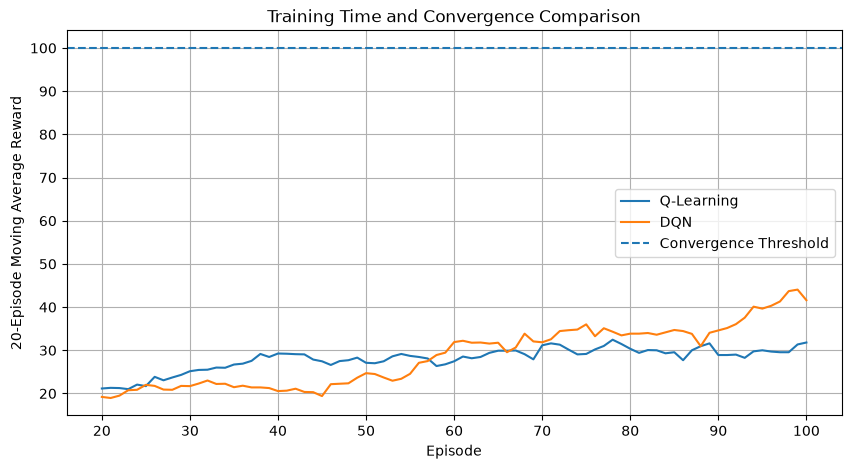

In [ ]:
import time
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Q-Learning Training
# -----------------------------
start_time = time.perf_counter()

q_learning_rewards = []

# Existing discretized Q-table from Q26
q_table = np.zeros((6, 6, 12, 12, 2))

learning_rate = 0.1
gamma = 0.99
epsilon = 1.0
epsilon_decay = 0.995
epsilon_min = 0.01

for episode in range(100):
    state, info = env.reset()
    state = discretize_state(state)

    total_reward = 0
    terminated = False
    truncated = False

    while not (terminated or truncated):

        if np.random.random() < epsilon:
            action = env.action_space.sample()
        else:
            action = np.argmax(q_table[state])

        next_state, reward, terminated, truncated, info = env.step(action)
        next_state = discretize_state(next_state)

        best_next_q = np.max(q_table[next_state])

        q_table[state][action] += learning_rate * (
            reward + gamma * best_next_q - q_table[state][action]
        )

        state = next_state
        total_reward += reward

    epsilon = max(epsilon_min, epsilon * epsilon_decay)
    q_learning_rewards.append(total_reward)

q_learning_time = time.perf_counter() - start_time


# -----------------------------
# DQN Training
# -----------------------------
start_time = time.perf_counter()

dqn_model, dqn_rewards = train_dqn(
    use_target_network=True,
    episodes=100
)

dqn_time = time.perf_counter() - start_time


# -----------------------------
# Convergence Analysis
# -----------------------------
def moving_average(rewards, window=20):
    return np.convolve(
        rewards,
        np.ones(window) / window,
        mode="valid"
    )


q_ma = moving_average(q_learning_rewards)
dqn_ma = moving_average(dqn_rewards)

# Chosen experimental convergence threshold
threshold = 100

q_convergence = next(
    (i + 20 for i, value in enumerate(q_ma) if value >= threshold),
    None
)

dqn_convergence = next(
    (i + 20 for i, value in enumerate(dqn_ma) if value >= threshold),
    None
)


# -----------------------------
# Results
# -----------------------------
print("========== Q-Learning vs DQN ==========")

print("\nQ-Learning Training Time:",
      round(q_learning_time, 3), "seconds")

print("DQN Training Time:",
      round(dqn_time, 3), "seconds")

print("\nQ-Learning Final Moving Average:",
      round(q_ma[-1], 2))

print("DQN Final Moving Average:",
      round(dqn_ma[-1], 2))

print("\nConvergence Threshold:", threshold)

print("Q-Learning Convergence Episode:",
      q_convergence if q_convergence else "Not reached")

print("DQN Convergence Episode:",
      dqn_convergence if dqn_convergence else "Not reached")


# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(10, 5))

plt.plot(
    range(20, 101),
    q_ma,
    label="Q-Learning"
)

plt.plot(
    range(20, 101),
    dqn_ma,
    label="DQN"
)

plt.axhline(
    threshold,
    linestyle="--",
    label="Convergence Threshold"
)

plt.xlabel("Episode")
plt.ylabel("20-Episode Moving Average Reward")
plt.title("Training Time and Convergence Comparison")

plt.legend()
plt.grid(True)
plt.show()

Testing Learning Rate: 0.0001
Testing Learning Rate: 0.001
Testing Learning Rate: 0.01
Testing Gamma: 0.9
Testing Gamma: 0.95
Testing Gamma: 0.99
Testing Initial Epsilon: 0.1
Testing Initial Epsilon: 0.5
Testing Initial Epsilon: 1.0

========== Learning Rate Results ==========
Learning Rate: 0.0001 | Average Reward: 20.04
Learning Rate: 0.001 | Average Reward: 24.5
Learning Rate: 0.01 | Average Reward: 22.48

========== Gamma Results ==========
Gamma: 0.9 | Average Reward: 25.4
Gamma: 0.95 | Average Reward: 34.62
Gamma: 0.99 | Average Reward: 24.0

========== Epsilon Results ==========
Initial Epsilon: 0.1 | Average Reward: 126.4
Initial Epsilon: 0.5 | Average Reward: 84.86
Initial Epsilon: 1.0 | Average Reward: 20.3


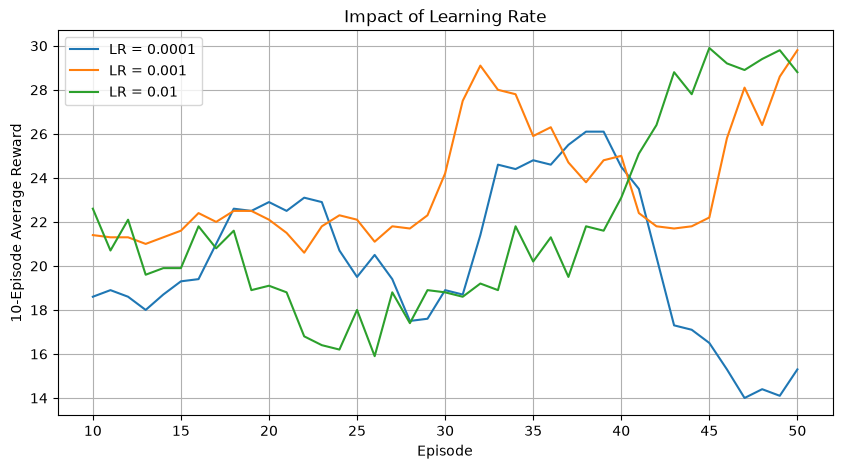

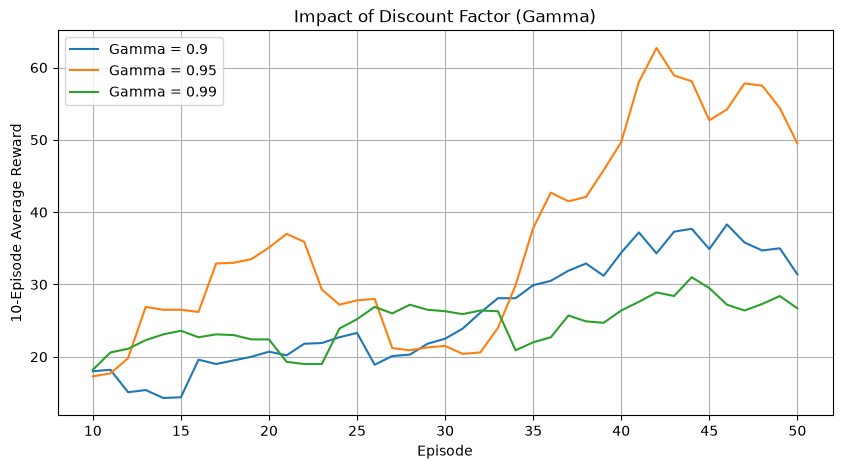

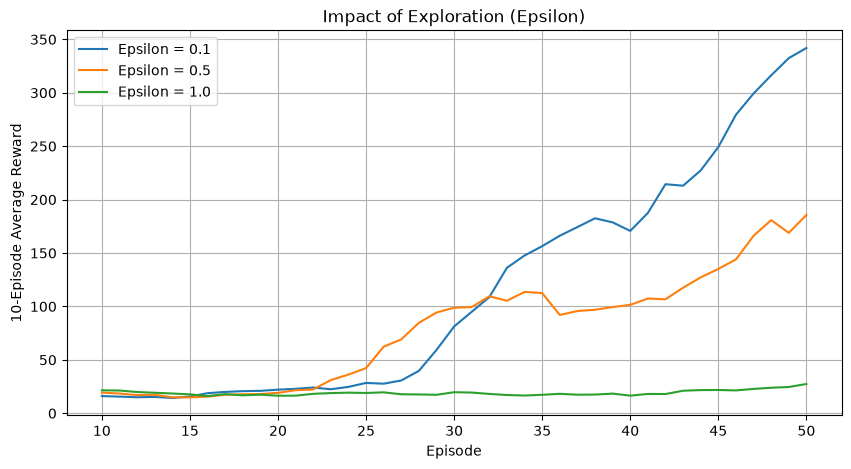

In [ ]:
import gymnasium as gym
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import random
from collections import deque
import matplotlib.pyplot as plt


# DQN Model
class DQN(nn.Module):
    def __init__(self, state_size, action_size):
        super(DQN, self).__init__()

        self.network = nn.Sequential(
            nn.Linear(state_size, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, action_size)
        )

    def forward(self, state):
        return self.network(state)


# Training function
def train_dqn(learning_rate=0.001,
              gamma=0.99,
              initial_epsilon=1.0,
              episodes=50):

    env = gym.make("CartPole-v1")

    state_size = env.observation_space.shape[0]
    action_size = env.action_space.n

    model = DQN(state_size, action_size)

    optimizer = optim.Adam(
        model.parameters(),
        lr=learning_rate
    )

    loss_function = nn.MSELoss()

    memory = deque(maxlen=10000)

    epsilon = initial_epsilon
    epsilon_min = 0.01
    epsilon_decay = 0.995

    batch_size = 64

    episode_rewards = []

    for episode in range(episodes):

        state, info = env.reset()

        total_reward = 0
        terminated = False
        truncated = False

        while not (terminated or truncated):

            # Epsilon-greedy action selection
            if random.random() < epsilon:
                action = env.action_space.sample()
            else:
                state_tensor = torch.tensor(
                    state,
                    dtype=torch.float32
                ).unsqueeze(0)

                with torch.no_grad():
                    action = torch.argmax(
                        model(state_tensor)
                    ).item()

            next_state, reward, terminated, truncated, info = env.step(action)

            done = terminated or truncated

            memory.append(
                (state, action, reward, next_state, done)
            )

            state = next_state
            total_reward += reward

            # Train when enough experiences are available
            if len(memory) >= batch_size:

                batch = random.sample(
                    memory,
                    batch_size
                )

                states = torch.tensor(
                    np.array([x[0] for x in batch]),
                    dtype=torch.float32
                )

                actions = torch.tensor(
                    [x[1] for x in batch],
                    dtype=torch.long
                )

                rewards = torch.tensor(
                    [x[2] for x in batch],
                    dtype=torch.float32
                )

                next_states = torch.tensor(
                    np.array([x[3] for x in batch]),
                    dtype=torch.float32
                )

                dones = torch.tensor(
                    [x[4] for x in batch],
                    dtype=torch.float32
                )

                current_q = model(states).gather(
                    1,
                    actions.unsqueeze(1)
                ).squeeze(1)

                with torch.no_grad():
                    next_q = model(next_states).max(1)[0]

                    target_q = rewards + (
                        gamma * next_q * (1 - dones)
                    )

                loss = loss_function(
                    current_q,
                    target_q
                )

                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

        epsilon = max(
            epsilon_min,
            epsilon * epsilon_decay
        )

        episode_rewards.append(total_reward)

    env.close()

    return episode_rewards


# ----------------------------------
# 1. Learning Rate Comparison
# ----------------------------------

learning_rates = [0.0001, 0.001, 0.01]

learning_rate_results = {}

for lr in learning_rates:

    print("Testing Learning Rate:", lr)

    rewards = train_dqn(
        learning_rate=lr,
        gamma=0.99,
        initial_epsilon=1.0,
        episodes=50
    )

    learning_rate_results[lr] = rewards


# ----------------------------------
# 2. Gamma Comparison
# ----------------------------------

gammas = [0.90, 0.95, 0.99]

gamma_results = {}

for gamma_value in gammas:

    print("Testing Gamma:", gamma_value)

    rewards = train_dqn(
        learning_rate=0.001,
        gamma=gamma_value,
        initial_epsilon=1.0,
        episodes=50
    )

    gamma_results[gamma_value] = rewards


# ----------------------------------
# 3. Epsilon Comparison
# ----------------------------------

epsilons = [0.1, 0.5, 1.0]

epsilon_results = {}

for epsilon_value in epsilons:

    print("Testing Initial Epsilon:", epsilon_value)

    rewards = train_dqn(
        learning_rate=0.001,
        gamma=0.99,
        initial_epsilon=epsilon_value,
        episodes=50
    )

    epsilon_results[epsilon_value] = rewards


# ----------------------------------
# Display Average Performance
# ----------------------------------

print("\n========== Learning Rate Results ==========")

for lr, rewards in learning_rate_results.items():

    print(
        "Learning Rate:",
        lr,
        "| Average Reward:",
        round(np.mean(rewards), 2)
    )


print("\n========== Gamma Results ==========")

for gamma_value, rewards in gamma_results.items():

    print(
        "Gamma:",
        gamma_value,
        "| Average Reward:",
        round(np.mean(rewards), 2)
    )


print("\n========== Epsilon Results ==========")

for epsilon_value, rewards in epsilon_results.items():

    print(
        "Initial Epsilon:",
        epsilon_value,
        "| Average Reward:",
        round(np.mean(rewards), 2)
    )


# ----------------------------------
# Graph 1: Learning Rate
# ----------------------------------

plt.figure(figsize=(10, 5))

for lr, rewards in learning_rate_results.items():

    moving_average = np.convolve(
        rewards,
        np.ones(10) / 10,
        mode="valid"
    )

    plt.plot(
        range(10, 51),
        moving_average,
        label=f"LR = {lr}"
    )

plt.xlabel("Episode")
plt.ylabel("10-Episode Average Reward")
plt.title("Impact of Learning Rate")
plt.legend()
plt.grid(True)
plt.show()


# ----------------------------------
# Graph 2: Gamma
# ----------------------------------

plt.figure(figsize=(10, 5))

for gamma_value, rewards in gamma_results.items():

    moving_average = np.convolve(
        rewards,
        np.ones(10) / 10,
        mode="valid"
    )

    plt.plot(
        range(10, 51),
        moving_average,
        label=f"Gamma = {gamma_value}"
    )

plt.xlabel("Episode")
plt.ylabel("10-Episode Average Reward")
plt.title("Impact of Discount Factor (Gamma)")
plt.legend()
plt.grid(True)
plt.show()


# ----------------------------------
# Graph 3: Epsilon
# ----------------------------------

plt.figure(figsize=(10, 5))

for epsilon_value, rewards in epsilon_results.items():

    moving_average = np.convolve(
        rewards,
        np.ones(10) / 10,
        mode="valid"
    )

    plt.plot(
        range(10, 51),
        moving_average,
        label=f"Epsilon = {epsilon_value}"
    )

plt.xlabel("Episode")
plt.ylabel("10-Episode Average Reward")
plt.title("Impact of Exploration (Epsilon)")
plt.legend()
plt.grid(True)
plt.show()

# Q35 - Comparative Report on Reinforcement Learning Algorithms

## Objective

The objective is to compare Reinforcement Learning algorithms
based on reward, learning curve, training time, convergence,
and hyperparameter impact.

## Algorithms Used

1. Q-Learning
2. Deep Q-Network (DQN)

## Environments Used

- FrozenLake-v1
- CartPole-v1
- Custom Grid World

## Q-Learning

Q-Learning uses a Q-table to store the values of state-action
pairs. The Q-table is updated using learning rate, gamma and
reward information.

## DQN

DQN uses a neural network to estimate Q-values. Experience
Replay and Target Network were used during the experiments.

## Performance Analysis

The algorithms were analyzed using:

- Episode Reward
- Cumulative Reward
- Learning Curve
- Training Time
- Convergence
- Hyperparameter Impact

## Hyperparameters

The effect of the following parameters was studied:

- Learning Rate
- Discount Factor (Gamma)
- Epsilon

## Observation

The experiments show that changing hyperparameters affects the
learning behavior and reward obtained by the agent.

Learning curves and moving averages were used to observe
learning progress and convergence.

## Conclusion

Q-Learning and DQN were successfully implemented and analyzed.
The experiments provided practical understanding of rewards,
convergence, training time and hyperparameter effects in
Reinforcement Learning.